In [6]:
#CESM plotting, Apr 8, Yingxiao & Danny
import numpy as np
import xarray as xr
import glob
import datetime
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import subprocess  # interact with derecho if linux commands if needed

import matplotlib.cm as cm
import cartopy.feature as cfeature

import matplotlib as mpl


def Plot_2D_proj_se (array_2D, scrip_filename, zlim=[0,1], projection=ccrs.Robinson(central_longitude= 0), cmap='viridis', extent=[-1,359,90,-90], labelsize=15, colorbar_size=([0.09, 0.06, 0.84, 0.04]), extend='both', figsize=[16,9], dpi=300, shading='flat', pad=15, orientation='horizontal'):

    
    # dmleung (6 Feb 2024): This is a function that tries to plot global data with different projections. Duseong's Plot_2D is good for regional data which most likely uses the PlateCarree projection. This function tries to extend that functionality to global data with different projections. The default projection is Robinson, but other projections, e.g., NearsidePerspective and Orthographic, are well tested and can be used here.
    # this function works for SE unstructured grids only. This function also only works for global inputs (array_2D should be global data).
    # It would be easy to combine this function with the Plot_2D_proj function above, but for now we seaparate them for easier debugging.
    # for now we assume this function is used for CESM history fields, which has a lon vector from 0° to 359° instead of -180° to 179°. If the latter is the case, change extent=[-180,180,90,-90]
    
    # nearside perspective is good for showing regional refinement if you are bored with plane projection: e.g., ccrs.NearsidePerspective(central_longitude= 110, central_latitude= 20, satellite_height=6785831) is probably good for ASIA-AQ maps
    # see all map projections in cartopy at: https://scitools.org.uk/cartopy/docs/v0.15/crs/projections.html

    # Note: https://github.com/SciTools/cartopy/issues/1293 gives the solution of plotting unstructured grid on other map projections. 3 Feb 2024 1:09 am Mountain time dmleung
    # tripcolor can be used to plot unstructured grids. However, it can only be used on the PlateCarree projection. To use tripcolor on other map projections, one need to also transform the points to the targeted projection (we call x and y here).
    # Also, although tripcolor is good for unstructured grids, one downside of it is that the grids on the maps are triangulated. It won't be clear on the global plots though. If one doesn't want triangulated grid, choose shading='gourand'.


    # first, get lon lat information from a scrip file. For now we assume the array_2D does not have the lon lat information (not everyone uses xarray to extract data from ncdf files).
    #scrip_filename = '/glade/campaign/acom/acom-weather/MUSICA/grids/ne30pg3/ne30pg3.nc'
    ds_scrip = xr.open_dataset( scrip_filename )
    lon_se = ds_scrip['lon']; lat_se = ds_scrip['lat']

    
    fig = plt.figure(figsize=figsize, dpi=dpi)
    
    x, y, _ = projection.transform_points(ccrs.PlateCarree(), lon_se.values, lat_se.values).T
    
    mask = np.invert(np.logical_or(np.isinf(x), np.isinf(y)))
    x = np.compress(mask, x)
    y = np.compress(mask, y)
    
    ax = plt.axes(projection=projection)
    
    dataplot = ax.tripcolor(x, y, array_2D , cmap=cmap, shading=shading, vmin=zlim[0], vmax=zlim[1])  # shading can be 'flat' or 'gouraud'. 'gouraud' gives more smoothed grids. I set the default to be 'flat' so we can see the grids a little more clearly.
    #ax.tripcolor(x, y, AODDUSTdn_se , cmap=cmap, shading=shading)  
    #ax.tricontourf(x, y, AODDUSTdn_se )
    #ax.tripcolor(lon_se1,lat_se,AODDUSTdn_se, shading='gouraud', cmap=Cbar(Cname='myct_cont').cmap)
    ax.coastlines(resolution='110m')
    ax.add_feature(cfeature.BORDERS.with_scale('110m'))
    
    # add grid lines every 45 deg
    gl = ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45), ylocs=np.arange(-90, 91, 45), linewidth=0.5)
    gl.rotate_labels = False; gl.top_labels = False; gl.bottom_labels = False

    cbar = plt.colorbar(dataplot, orientation=orientation, cax=fig.add_axes(colorbar_size), extend=extend);
    cbar.ax.tick_params(labelsize=labelsize)  # labelsize is colorbar tick font size
    #cbar.ax.xaxis.set_tick_params(pad=30)
    #cbar.ax.xaxis.tick_params(pad=30)
    cbar.ax.xaxis.set_tick_params(pad=pad)  # here, pad controls the gap between tick labels and the colorbar







In [7]:
ds = xr.open_dataset("/glade/derecho/scratch/yingxiao/archive/EU2_off_2007.nc")
scrip_filename = "/glade/derecho/scratch/yingxiao/archive/EU2_off_2007.nc"
ds.data_vars

Data variables:
    Ruptured_pol_num   (ncol) float64 389kB ...
    Ruptured_pol_mass  (ncol) float64 389kB ...
    pol_num            (ncol) float64 389kB ...
    pol_mass           (ncol) float64 389kB ...
    pol_emis           (ncol) float64 389kB ...
    lat                (grid_size) float64 389kB ...
    lon                (grid_size) float64 389kB ...

Text(0.5, 0.88, 'Annual Average Ruptured Pollen concentration (grains/m3)')

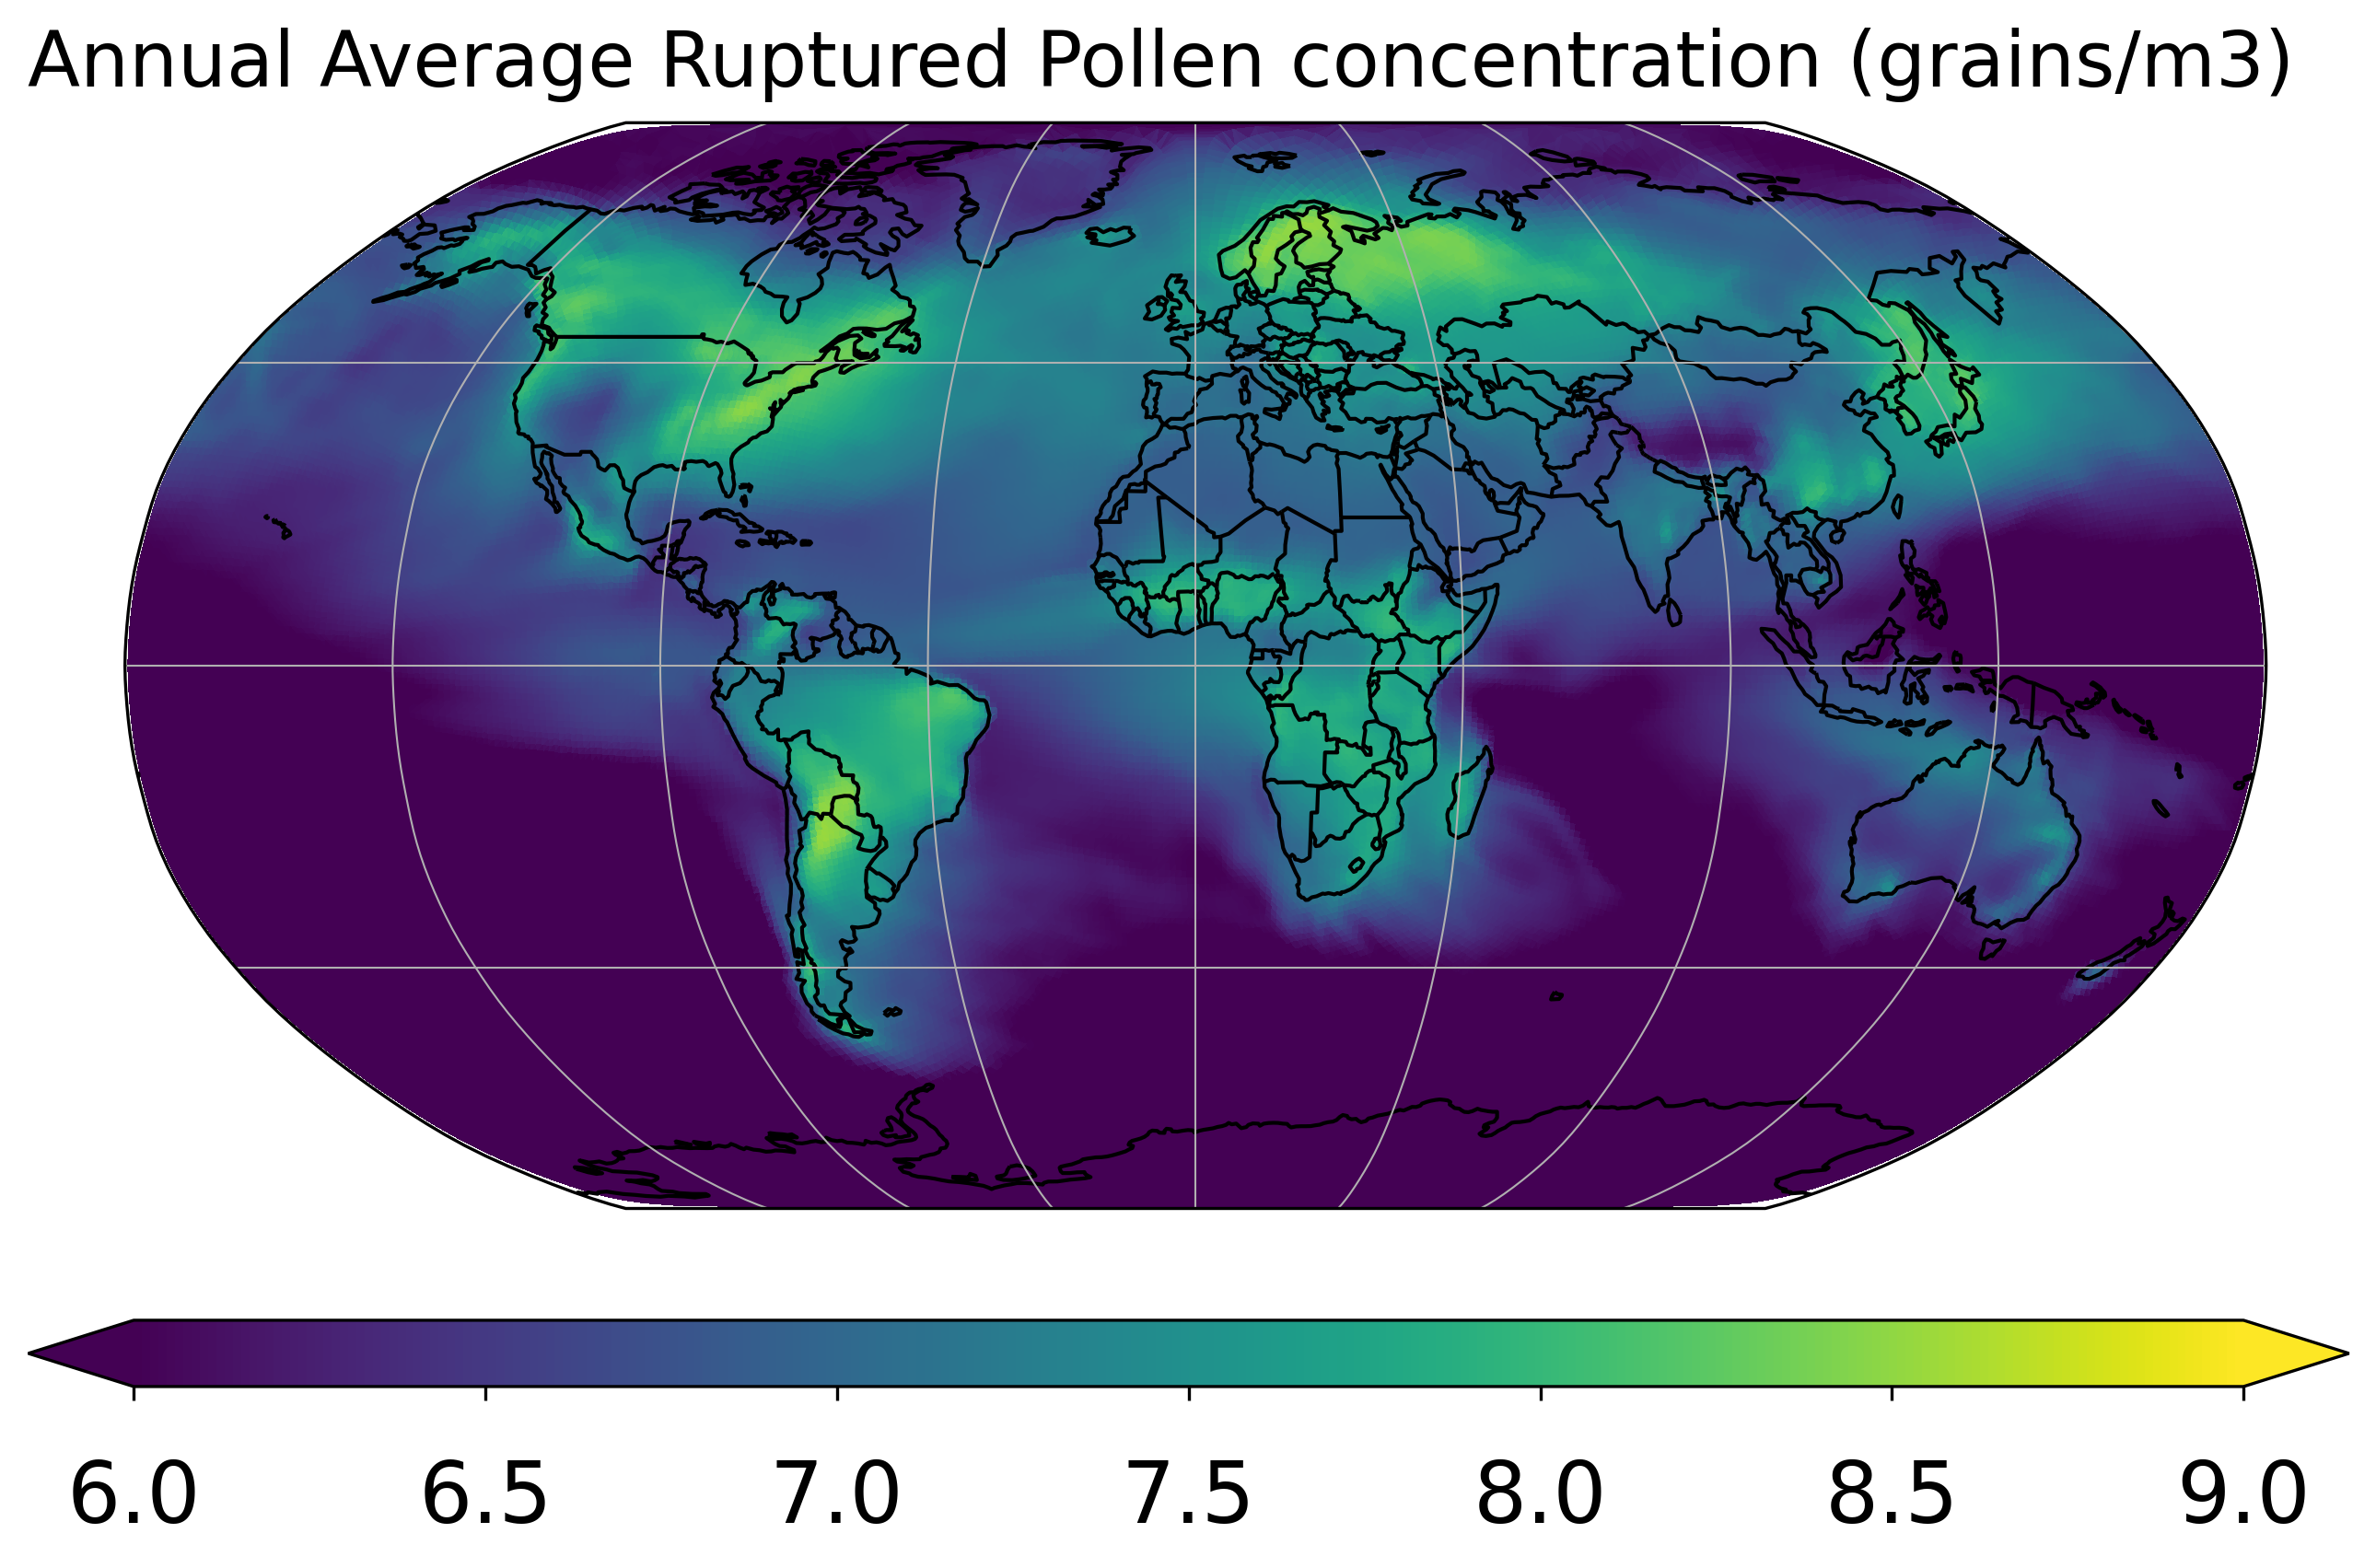

In [8]:
Plot_2D_proj_se(array_2D=np.log10(ds["Ruptured_pol_num"]), scrip_filename=scrip_filename, zlim=[6,9], projection=ccrs.Robinson(central_longitude=0), 
             labelsize=22, cmap='viridis', figsize=[10,6])
#plt.suptitle('AODDUSTdn baseline156_expldiffF_quadtune.001', fontsize=20, y=0.88)
plt.suptitle('Annual Average Ruptured Pollen concentration (grains/m3)', fontsize=20, y=0.88)
